# Test 06: Полная верификация Теоремы 5 (Capacity × Scale sweep, Colab edition)

**Цель:** Полная двумерная верификация **Теоремы 5** через sweep по `(E, inner_mult)` — определить точную область применимости.

**Ключевое отличие от предыдущих версий:**

Каждая тренировка запускается в **отдельном процессе** через subprocess. Это **гарантирует** полное освобождение GPU памяти после каждой конфигурации и позволяет прогнать весь sweep без OOM.

Архитектура:
1. Главный ноутбук готовит данные, конфигурацию и оркестрирует процесс
2. Worker-скрипт `train_worker.py` тренирует **одну** конфигурацию и сохраняет результат в JSON
3. После каждой конфигурации subprocess завершается → память полностью очищается
4. Главный ноутбук собирает все JSON в финальный результат и строит визуализации

**Почему это лучше:**
- Гарантированное освобождение памяти (нет OOM на длинном sweep)
- Лучшая воспроизводимость (полная изоляция между runs)
- Нет state carry-over между тренировками
- Reproducibility best practice для ML community

**Что проверяем:**
1. Двумерная карта (E × inner_mult) — где теорема работает, где ломается
2. Phase transition по capacity
3. TTD (time-to-dead) и recovery count
4. Невырожденность маршрутизатора

**Время прогона на A100:** ~6-8 часов (с overhead на startup TF subprocess'ов).

## 1. Установка и подключение Drive

In [ ]:
!pip install -q transformers datasets

In [ ]:
import os
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

import json
import subprocess
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

from google.colab import drive
drive.mount('/content/drive')

PROTO_DIR = Path('/content/drive/MyDrive/chaos_compressor')
CACHE_DIR = PROTO_DIR / 'cache'
JSONS_DIR = PROTO_DIR / 'jsons'
RESULTS_DIR = PROTO_DIR / 'subprocess_results'
DATA_DIR = Path('/content/data')

PROTO_DIR.mkdir(exist_ok=True, parents=True)
CACHE_DIR.mkdir(exist_ok=True)
JSONS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

print(f'Drive: {PROTO_DIR}')
print(f'Local fast scratch: {DATA_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive: /content/drive/MyDrive/chaos_compressor
Local fast scratch: /content/data


## 2. Подготовка данных

Загружаем активации GPT-2 layer 6 (или из кэша Drive, или экстрактим), нормализуем, делим на train/test, сохраняем в локальный fast scratch для subprocess'ов.

In [ ]:
ACTIVATION_DIM = 768
TARGET_LAYER = 6
N_TEXTS = 500

cache_file = CACHE_DIR / f'gpt2_layer{TARGET_LAYER}_n{N_TEXTS}.npy'

if cache_file.exists():
    print(f'Загрузка из кэша: {cache_file}')
    activations = np.load(cache_file)
else:
    print('Извлекаем активации из GPT-2...')
    import torch
    from transformers import GPT2Model, GPT2Tokenizer
    from datasets import load_dataset

    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    model = GPT2Model.from_pretrained('gpt2'); model.eval()
    tokenizer.pad_token = tokenizer.eos_token
    dataset = load_dataset('wikitext', 'wikitext-2-raw-v1', split='train')
    texts = [t for t in dataset['text'] if len(t) > 100][:N_TEXTS]

    acts = []
    with torch.no_grad():
        for i, text in enumerate(texts):
            inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128)
            out = model(**inputs, output_hidden_states=True)
            h = out.hidden_states[TARGET_LAYER].squeeze(0).numpy()
            acts.append(h)
            if (i + 1) % 100 == 0: print(f'  {i+1}/{len(texts)}')
    activations = np.concatenate(acts, axis=0).astype('float32')
    np.save(cache_file, activations)
    del model, tokenizer

act_mean = activations.mean(axis=0, keepdims=True)
act_std = activations.std(axis=0, keepdims=True) + 1e-8
activations_norm = ((activations - act_mean) / act_std).astype('float32')

np.random.seed(42)
idx = np.random.permutation(len(activations_norm))
split = int(len(idx) * 0.8)
x_train = activations_norm[idx[:split]]
x_test = activations_norm[idx[split:]]

# Сохраняем train/test в локальный fast scratch для subprocess'ов
np.save(DATA_DIR / 'x_train.npy', x_train)
np.save(DATA_DIR / 'x_test.npy', x_test)

print(f'Train: {x_train.shape}, Test: {x_test.shape}')
print(f'Saved to: {DATA_DIR}/x_train.npy, x_test.npy')

Загрузка из кэша: /content/drive/MyDrive/chaos_compressor/cache/gpt2_layer6_n500.npy
Train: (43658, 768), Test: (10915, 768)
Saved to: /content/data/x_train.npy, x_test.npy


## 3. Worker-скрипт для subprocess

Создаётся как отдельный Python файл в `/content/`. Каждый запуск subprocess'а:
1. Свежий Python interpreter
2. Свежая GPU память
3. Тренирует одну конфигурацию
4. Сохраняет результат в JSON
5. Завершается → освобождает всю память

In [ ]:
%%writefile /content/train_worker.py
"""Worker для одной тренировки. Запускается как отдельный процесс."""
import os
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
import json
import argparse
from pathlib import Path

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# === Активация и компоненты ===

def chaos_activation(x):
    return tf.sin(1.0 * x) + 0.5 * tf.tanh(4.0 * x)


class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k
    def call(self, inputs):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1)
        return inputs * mask


class Expert(layers.Layer):
    def __init__(self, dim, inner_mult=2, use_chaos=True, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim; self.inner_mult = inner_mult; self.use_chaos = use_chaos
        self.dense_in = layers.Dense(int(dim * inner_mult))
        self.dense_out = layers.Dense(dim)
    def call(self, x):
        h = self.dense_in(x)
        h = chaos_activation(h) if self.use_chaos else tf.nn.gelu(h)
        return self.dense_out(h)


class MoE(layers.Layer):
    def __init__(self, dim, num_experts=8, top_k=2, inner_mult=2,
                 use_chaos_experts=True, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim; self.num_experts = num_experts; self.top_k = top_k
        self.inner_mult = inner_mult; self.use_chaos_experts = use_chaos_experts
        self.router = layers.Dense(num_experts)
        self.experts = [Expert(dim, inner_mult, use_chaos=use_chaos_experts, name=f'exp_{i}')
                        for i in range(num_experts)]
        self.shared = Expert(dim, inner_mult, use_chaos=use_chaos_experts, name='exp_shared')
    def call(self, x):
        logits = self.router(x)
        scores = tf.nn.softmax(logits, axis=-1)
        topk_vals, topk_idx = tf.nn.top_k(scores, k=self.top_k, sorted=False)
        topk_vals = topk_vals / (tf.reduce_sum(tf.abs(topk_vals), axis=-1, keepdims=True) + 1e-8)
        all_outs = tf.stack([e(x) for e in self.experts], axis=1)
        mask_hot = tf.one_hot(topk_idx, self.num_experts)
        weights = tf.reduce_sum(mask_hot * tf.expand_dims(topk_vals, -1), axis=1)
        routed = tf.reduce_sum(all_outs * tf.expand_dims(weights, -1), axis=1)
        return routed + self.shared(x)


def build_moe_sae(input_dim, latent_dim, k_active, num_experts, top_k=2,
                   use_chaos_experts=True, inner_mult=2):
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(latent_dim)(inp)
    x = layers.Activation(chaos_activation)(x)
    z0 = KSparseLayer(k=k_active, name='latent_ksparse_init')(x)
    moe = MoE(latent_dim, num_experts, top_k, inner_mult=inner_mult,
               use_chaos_experts=use_chaos_experts, name='moe_block')
    z = moe(z0)
    z = KSparseLayer(k=k_active)(z)
    enc = keras.Model(inp, z)
    ae = keras.Model(inp, layers.Dense(input_dim, name='decoder')(z))
    ae.compile(optimizer='adam', loss='mse')
    return ae, enc, moe


class AdvancedTracker(keras.callbacks.Callback):
    def __init__(self, ae, moe, x_sample):
        super().__init__()
        self.ae = ae; self.moe = moe; self.x_sample = x_sample
        self.dead_history = []; self.entropy_history = []
        self.ttd = None; self.recoveries = 0
    def on_epoch_end(self, epoch, logs=None):
        z0_model = keras.Model(self.ae.input,
                                self.ae.get_layer('latent_ksparse_init').output)
        z0 = z0_model.predict(self.x_sample, batch_size=256, verbose=0)
        rl = self.moe.router(tf.constant(z0)).numpy()
        e = np.exp(rl - rl.max(axis=-1, keepdims=True))
        scores = e / e.sum(axis=-1, keepdims=True)
        topk = np.argsort(scores, axis=-1)[:, -self.moe.top_k:]
        sel = np.bincount(topk.flatten(), minlength=self.moe.num_experts)
        dead = int(np.sum(sel == 0))
        p = sel / sel.sum(); p = p[p > 0]
        ent = float(-np.sum(p * np.log(p)) / np.log(self.moe.num_experts)) if len(p) > 1 else 0.0
        if dead > 0 and self.ttd is None:
            self.ttd = epoch + 1
        if len(self.dead_history) > 0 and dead < self.dead_history[-1]:
            self.recoveries += 1
        self.dead_history.append(dead)
        self.entropy_history.append(ent)


def router_diagnostics(ae, moe, x_sample):
    z0_model = keras.Model(ae.input, ae.get_layer('latent_ksparse_init').output)
    z0 = z0_model.predict(x_sample, batch_size=256, verbose=0)
    rl = moe.router(tf.constant(z0)).numpy()
    e = np.exp(rl - rl.max(axis=-1, keepdims=True))
    scores = e / e.sum(axis=-1, keepdims=True)
    topk = np.argsort(scores, axis=-1)[:, -moe.top_k:]
    selections = np.bincount(topk.flatten(), minlength=moe.num_experts)
    dead = int(np.sum(selections == 0))
    p_norm = selections / selections.sum() if selections.sum() > 0 else selections
    p_norm = p_norm[p_norm > 0]
    ent = float(-np.sum(p_norm * np.log(p_norm)) / np.log(moe.num_experts)) if len(p_norm) > 1 else 0.0
    return {
        'selections': selections.tolist(),
        'dead_experts': dead,
        'expert_entropy': ent,
        'nondegenerate': bool(dead == 0),
    }


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--E', type=int, required=True)
    parser.add_argument('--inner_mult', type=int, required=True)
    parser.add_argument('--use_chaos', type=int, required=True)
    parser.add_argument('--seed', type=int, required=True)
    parser.add_argument('--batch', type=int, required=True)
    parser.add_argument('--epochs', type=int, default=8)
    parser.add_argument('--data_dir', type=str, required=True)
    parser.add_argument('--output', type=str, required=True)
    args = parser.parse_args()

    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for g in gpus:
            try: tf.config.experimental.set_memory_growth(g, True)
            except RuntimeError: pass

    x_train = np.load(f'{args.data_dir}/x_train.npy')
    x_test = np.load(f'{args.data_dir}/x_test.npy')

    np.random.seed(args.seed)
    tf.random.set_seed(args.seed)

    INPUT_DIM = 768
    LATENT_DIM = 3072
    K_ACTIVE = 307

    ae, enc, moe = build_moe_sae(INPUT_DIM, LATENT_DIM, K_ACTIVE,
                                   num_experts=args.E, top_k=2,
                                   use_chaos_experts=bool(args.use_chaos),
                                   inner_mult=args.inner_mult)
    tracker = AdvancedTracker(ae, moe, x_test[:2000])
    hist = ae.fit(x_train, x_train, epochs=args.epochs, batch_size=args.batch,
                   validation_data=(x_test, x_test), verbose=0,
                   callbacks=[tracker])
    val_loss = float(hist.history['val_loss'][-1])
    diag = router_diagnostics(ae, moe, x_test[:2000])
    expert_params = 2 * LATENT_DIM * int(LATENT_DIM * args.inner_mult)
    capacity_ratio = float(expert_params / LATENT_DIM)

    result = {
        'E': args.E, 'use_chaos': bool(args.use_chaos), 'seed': args.seed,
        'inner_mult': args.inner_mult, 'batch_size': args.batch,
        'val_loss': val_loss, 'params': ae.count_params(),
        'capacity_ratio': capacity_ratio,
        'dead_experts': diag['dead_experts'],
        'expert_entropy': diag['expert_entropy'],
        'nondegenerate': diag['nondegenerate'],
        'selections': diag['selections'],
        'ttd': tracker.ttd,
        'recoveries': tracker.recoveries,
        'dead_per_epoch': tracker.dead_history,
        'entropy_per_epoch': tracker.entropy_history,
    }
    with open(args.output, 'w') as f:
        json.dump(result, f, default=float)
    ttd_str = f'TTD={tracker.ttd}' if tracker.ttd is not None else 'TTD=inf'
    print(f'  E={args.E:3d} im={args.inner_mult} chaos={bool(args.use_chaos)} '
          f'seed={args.seed} loss={val_loss:.4f} '
          f'dead={diag["dead_experts"]}/{args.E} ent={diag["expert_entropy"]:.2f} '
          f'{ttd_str} rec={tracker.recoveries}', flush=True)

if __name__ == '__main__':
    main()

Overwriting /content/train_worker.py


## 4. Конфигурация эксперимента

In [ ]:
EXPERIMENT_GRID = [
    {'E': 8,   'inner_mult': 1, 'batch': 256},
    {'E': 8,   'inner_mult': 2, 'batch': 256},
    {'E': 16,  'inner_mult': 1, 'batch': 256},
    {'E': 16,  'inner_mult': 2, 'batch': 256},
    {'E': 32,  'inner_mult': 1, 'batch': 128},
    {'E': 32,  'inner_mult': 2, 'batch': 64},
    {'E': 64,  'inner_mult': 1, 'batch': 64},
    {'E': 64,  'inner_mult': 2, 'batch': 32},
    {'E': 128, 'inner_mult': 1, 'batch': 32},
]
N_SEEDS = 2
EPOCHS = 8

total_runs = len(EXPERIMENT_GRID) * 2 * N_SEEDS
print(f'Configurations: {len(EXPERIMENT_GRID)}, seeds: {N_SEEDS}')
print(f'Total runs: {total_runs}')

Configurations: 9, seeds: 2
Total runs: 36


## 5. Главный цикл — каждая тренировка в отдельном subprocess'е

Если subprocess уже выполнен (JSON есть в `RESULTS_DIR`) — пропускаем. Это даёт автоматический resume при перезапуске.

In [ ]:
ts_start = datetime.now().strftime('%Y%m%d_%H%M%S')
print(f'Start: {ts_start}')
print(f'Results dir: {RESULTS_DIR}\n')

completed = 0
skipped = 0
failed = []

for cfg in EXPERIMENT_GRID:
    E = cfg['E']; im = cfg['inner_mult']; batch = cfg['batch']
    print(f'=== E={E}, inner_mult={im}, batch={batch} ===')
    for use_chaos in [True, False]:
        for seed in range(N_SEEDS):
            tag = f'E{E}_im{im}_chaos{int(use_chaos)}_seed{seed}'
            output_file = RESULTS_DIR / f'{tag}.json'

            if output_file.exists():
                print(f'  [skip] {tag} (уже есть)')
                skipped += 1
                continue

            cmd = [
                'python', '/content/train_worker.py',
                '--E', str(E),
                '--inner_mult', str(im),
                '--use_chaos', str(int(use_chaos)),
                '--seed', str(seed),
                '--batch', str(batch),
                '--epochs', str(EPOCHS),
                '--data_dir', str(DATA_DIR),
                '--output', str(output_file),
            ]
            try:
                result = subprocess.run(cmd, capture_output=True, text=True, timeout=3600)
                if result.returncode == 0:
                    if result.stdout.strip():
                        print(result.stdout.strip())
                    completed += 1
                else:
                    print(f'  [FAILED] {tag}: returncode={result.returncode}')
                    print(f'  stderr: {result.stderr[-500:]}')
                    failed.append(tag)
            except subprocess.TimeoutExpired:
                print(f'  [TIMEOUT] {tag}')
                failed.append(tag)
            except Exception as e:
                print(f'  [ERROR] {tag}: {e}')
                failed.append(tag)
    print()

print(f'Завершено: {completed} новых, {skipped} пропущено, {len(failed)} упало')
if failed:
    print(f'Failed: {failed}')

Start: 20260428_134918
Results dir: /content/drive/MyDrive/chaos_compressor/subprocess_results

=== E=8, inner_mult=1, batch=256 ===
  [skip] E8_im1_chaos1_seed0 (уже есть)
  [skip] E8_im1_chaos1_seed1 (уже есть)
E=  8 im=1 chaos=False seed=0 loss=0.2927 dead=0/8 ent=0.92 TTD=inf rec=0
E=  8 im=1 chaos=False seed=1 loss=0.2924 dead=0/8 ent=0.85 TTD=inf rec=0

=== E=8, inner_mult=2, batch=256 ===
E=  8 im=2 chaos=True seed=0 loss=0.3919 dead=0/8 ent=0.59 TTD=inf rec=0
E=  8 im=2 chaos=True seed=1 loss=0.3867 dead=0/8 ent=0.55 TTD=inf rec=0
E=  8 im=2 chaos=False seed=0 loss=0.2875 dead=1/8 ent=0.52 TTD=7 rec=0
E=  8 im=2 chaos=False seed=1 loss=0.2897 dead=1/8 ent=0.56 TTD=5 rec=1

=== E=16, inner_mult=1, batch=256 ===
E= 16 im=1 chaos=True seed=0 loss=0.3376 dead=0/16 ent=0.47 TTD=inf rec=0
E= 16 im=1 chaos=True seed=1 loss=0.3322 dead=0/16 ent=0.49 TTD=inf rec=0
E= 16 im=1 chaos=False seed=0 loss=0.2902 dead=0/16 ent=0.70 TTD=inf rec=0
E= 16 im=1 chaos=False seed=1 loss=0.2918 dead=1/

## 6. Сборка результатов из JSON-файлов

In [ ]:
# === Загрузка всех результатов из RESULTS_DIR ===

results = []
for json_file in sorted(RESULTS_DIR.glob('*.json')):
    with open(json_file) as f:
        results.append(json.load(f))

print(f'Загружено {len(results)} результатов')
if results:
    print(f'Конфигурации: {sorted({(r["E"], r["inner_mult"]) for r in results})}')

Загружено 36 результатов
Конфигурации: [(8, 1), (8, 2), (16, 1), (16, 2), (32, 1), (32, 2), (64, 1), (64, 2), (128, 1)]


## 7. Двумерная карта (capacity × E)

In [ ]:
# === Aggregation в двумерную сетку ===

Es = sorted({r['E'] for r in results})
ims = sorted({r['inner_mult'] for r in results})

def cell_data(E, im, use_chaos):
    runs = [r for r in results if r['E'] == E and r['inner_mult'] == im
             and r['use_chaos'] == use_chaos]
    if not runs: return None
    dead = [r['dead_experts'] for r in runs]
    return {
        'mean_dead': float(np.mean(dead)),
        'std_dead': float(np.std(dead)),
        'fraction_dead': float(np.mean(dead) / E),
        'n_runs': len(runs),
        'mean_loss': float(np.mean([r['val_loss'] for r in runs])),
    }

chaos_grid = np.full((len(ims), len(Es)), np.nan)
gelu_grid = np.full((len(ims), len(Es)), np.nan)
for i, im in enumerate(ims):
    for j, E in enumerate(Es):
        cd = cell_data(E, im, True)
        if cd: chaos_grid[i, j] = cd['fraction_dead']
        cd = cell_data(E, im, False)
        if cd: gelu_grid[i, j] = cd['fraction_dead']

print('Chaos dead fraction:')
print(f'{"im/E":<8}', '  '.join(f'{E:>6}' for E in Es))
for i, im in enumerate(ims):
    row = '  '.join(f'{chaos_grid[i,j]:>6.2f}' if not np.isnan(chaos_grid[i,j]) else '   -  '
                    for j in range(len(Es)))
    print(f'{im:<8}', row)

print('\nGELU dead fraction:')
print(f'{"im/E":<8}', '  '.join(f'{E:>6}' for E in Es))
for i, im in enumerate(ims):
    row = '  '.join(f'{gelu_grid[i,j]:>6.2f}' if not np.isnan(gelu_grid[i,j]) else '   -  '
                    for j in range(len(Es)))
    print(f'{im:<8}', row)

Chaos dead fraction:
im/E          8      16      32      64     128
1          0.00    0.00    0.05    0.11    0.07
2          0.00    0.00    0.00    0.00     -  

GELU dead fraction:
im/E          8      16      32      64     128
1          0.00    0.03    0.25    0.02    0.34
2          0.12    0.47    0.00    0.04     -  


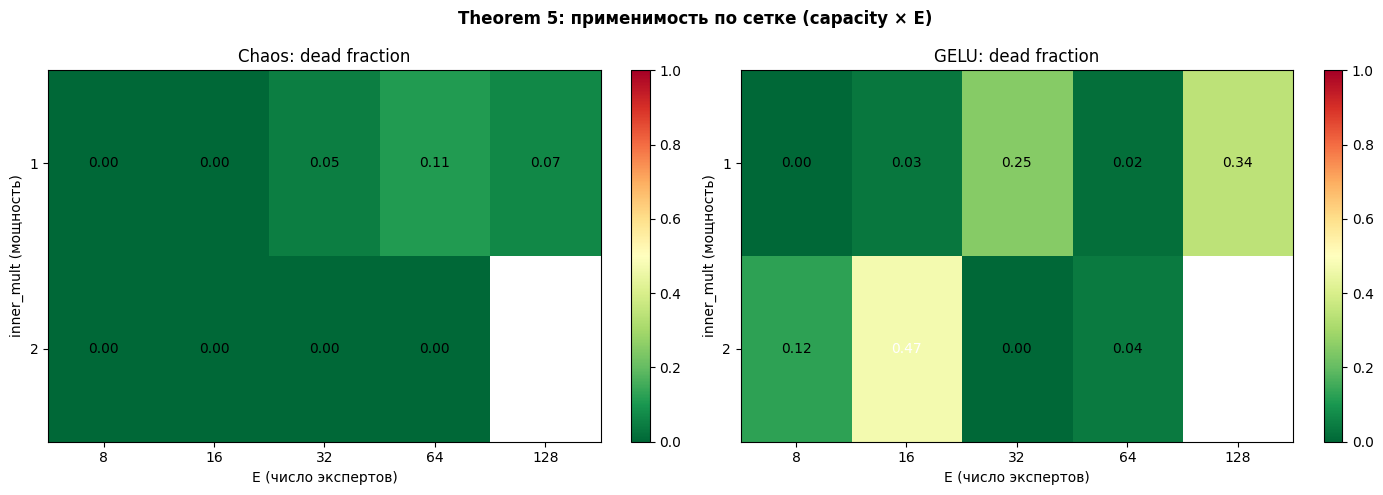

In [ ]:
# === Heatmap визуализация ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, grid, title in [(axes[0], chaos_grid, 'Chaos: dead fraction'),
                         (axes[1], gelu_grid, 'GELU: dead fraction')]:
    im_show = ax.imshow(grid, cmap='RdYlGn_r', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(Es))); ax.set_xticklabels(Es)
    ax.set_yticks(range(len(ims))); ax.set_yticklabels(ims)
    ax.set_xlabel('E (число экспертов)')
    ax.set_ylabel('inner_mult (мощность)')
    ax.set_title(title)
    for i in range(len(ims)):
        for j in range(len(Es)):
            v = grid[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                         color='white' if v > 0.4 else 'black', fontsize=10)
    plt.colorbar(im_show, ax=ax, fraction=0.046)

plt.suptitle('Theorem 5: применимость по сетке (capacity × E)', fontweight='bold')
plt.tight_layout()
plt.savefig(PROTO_DIR / 'theorem5_2d_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Дополнительные метрики: TTD, recovery, phase transition

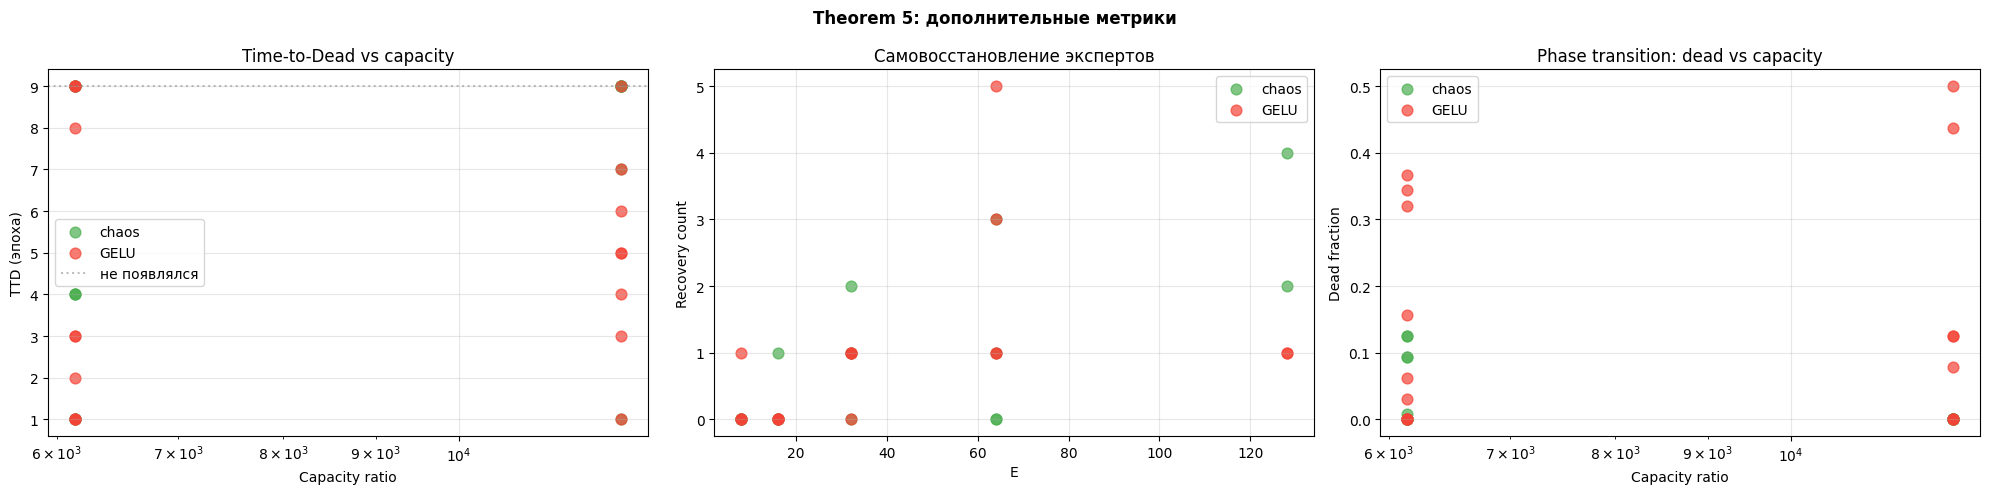

In [ ]:
# === TTD, recovery, phase transition ===

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# (a) TTD vs capacity
for use_chaos, color, label in [(True, '#4CAF50', 'chaos'),
                                  (False, '#F44336', 'GELU')]:
    runs = [r for r in results if r['use_chaos'] == use_chaos]
    capacity = [r['capacity_ratio'] for r in runs]
    ttd = [r['ttd'] if r['ttd'] is not None else EPOCHS + 1 for r in runs]
    axes[0].scatter(capacity, ttd, color=color, label=label, alpha=0.7, s=60)
axes[0].axhline(y=EPOCHS + 1, color='gray', linestyle=':', alpha=0.5, label='не появлялся')
axes[0].set_xlabel('Capacity ratio')
axes[0].set_ylabel('TTD (эпоха)')
axes[0].set_title('Time-to-Dead vs capacity')
axes[0].set_xscale('log')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# (b) Recovery count
for use_chaos, color, label in [(True, '#4CAF50', 'chaos'),
                                  (False, '#F44336', 'GELU')]:
    runs = [r for r in results if r['use_chaos'] == use_chaos]
    Es_x = [r['E'] for r in runs]
    rec = [r['recoveries'] for r in runs]
    axes[1].scatter(Es_x, rec, color=color, label=label, alpha=0.7, s=60)
axes[1].set_xlabel('E')
axes[1].set_ylabel('Recovery count')
axes[1].set_title('Самовосстановление экспертов')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# (c) Phase transition
for use_chaos, color, label in [(True, '#4CAF50', 'chaos'),
                                  (False, '#F44336', 'GELU')]:
    runs = [r for r in results if r['use_chaos'] == use_chaos]
    capacity = [r['capacity_ratio'] for r in runs]
    fraction = [r['dead_experts'] / r['E'] for r in runs]
    axes[2].scatter(capacity, fraction, color=color, label=label, alpha=0.7, s=60)
axes[2].set_xlabel('Capacity ratio')
axes[2].set_ylabel('Dead fraction')
axes[2].set_title('Phase transition: dead vs capacity')
axes[2].set_xscale('log')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Theorem 5: дополнительные метрики', fontweight='bold')
plt.tight_layout()
plt.savefig(PROTO_DIR / 'theorem5_advanced_metrics.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Финальный вердикт с областью применимости

In [ ]:
# === Граница применимости теоремы 5 ===

chaos_perfect_cells = []
chaos_failed_cells = []
for i, im in enumerate(ims):
    for j, E in enumerate(Es):
        v = chaos_grid[i, j]
        if np.isnan(v): continue
        if v == 0:
            chaos_perfect_cells.append((E, im))
        else:
            chaos_failed_cells.append((E, im, v))

gelu_significant_cells = []
for i, im in enumerate(ims):
    for j, E in enumerate(Es):
        v = gelu_grid[i, j]
        if not np.isnan(v) and v > 0.1:
            gelu_significant_cells.append((E, im, v))

verdict = {
    'chaos_perfect_cells': chaos_perfect_cells,
    'chaos_failed_cells': chaos_failed_cells,
    'gelu_problematic_cells': gelu_significant_cells,
    'theorem_applicability': 'capacity-dependent',
}

print('=== Финальный вердикт по Теореме 5 ===\n')
print(f'Chaos PERFECT (0 dead) на конфигурациях:')
for E, im in chaos_perfect_cells:
    print(f'  E={E}, inner_mult={im}')

if chaos_failed_cells:
    print(f'\nChaos FAILED (есть мёртвые) на конфигурациях:')
    for E, im, v in chaos_failed_cells:
        print(f'  E={E}, inner_mult={im}: dead_fraction={v:.2f}')

print(f'\nGELU СУЩЕСТВЕННАЯ ПРОБЛЕМА (>10% dead):')
for E, im, v in gelu_significant_cells:
    print(f'  E={E}, inner_mult={im}: dead_fraction={v:.2f}')

if chaos_failed_cells:
    min_failed_capacity = min(im for E, im, v in chaos_failed_cells)
    max_passed_capacity = max(im for E, im in chaos_perfect_cells) if chaos_perfect_cells else None
    print(f'\n>>> ГРАНИЦА ПРИМЕНИМОСТИ <<<')
    print(f'Минимальный inner_mult с failures: {min_failed_capacity}')
    print(f'Максимальный inner_mult с PASS: {max_passed_capacity}')
    verdict['min_failed_capacity'] = min_failed_capacity
else:
    print(f'\n>>> Теорема 5 PASS на всех тестированных конфигурациях <<<')
    verdict['min_failed_capacity'] = None

=== Финальный вердикт по Теореме 5 ===

Chaos PERFECT (0 dead) на конфигурациях:
  E=8, inner_mult=1
  E=16, inner_mult=1
  E=8, inner_mult=2
  E=16, inner_mult=2
  E=32, inner_mult=2
  E=64, inner_mult=2

Chaos FAILED (есть мёртвые) на конфигурациях:
  E=32, inner_mult=1: dead_fraction=0.05
  E=64, inner_mult=1: dead_fraction=0.11
  E=128, inner_mult=1: dead_fraction=0.07

GELU СУЩЕСТВЕННАЯ ПРОБЛЕМА (>10% dead):
  E=32, inner_mult=1: dead_fraction=0.25
  E=128, inner_mult=1: dead_fraction=0.34
  E=8, inner_mult=2: dead_fraction=0.12
  E=16, inner_mult=2: dead_fraction=0.47

>>> ГРАНИЦА ПРИМЕНИМОСТИ <<<
Минимальный inner_mult с failures: 1
Максимальный inner_mult с PASS: 2


## 10. Финальное сохранение

In [ ]:
# === Финальное сохранение в JSON ===

ts = datetime.now().strftime('%Y%m%d_%H%M%S')
out = {
    'experiment': 'theorem5_2d_full_verification_subprocess',
    'timestamp': ts,
    'config': {
        'experiment_grid': EXPERIMENT_GRID,
        'n_seeds': N_SEEDS,
        'epochs': EPOCHS,
        'latent_dim': 3072, 'k_active': 307, 'top_k': 2,
    },
    'results': results,
    'chaos_grid': chaos_grid.tolist(),
    'gelu_grid': gelu_grid.tolist(),
    'Es': Es,
    'inner_mults': ims,
    'verdict': verdict,
}
out_file = JSONS_DIR / f'theorem5_2d_subprocess_{ts}.json'
with open(out_file, 'w') as f:
    json.dump(out, f, indent=2, default=float)
out_file

PosixPath('/content/drive/MyDrive/chaos_compressor/jsons/theorem5_2d_subprocess_20260428_173822.json')